In [1]:
import os,sys

# Set the path to the parent directory manually
parent_dir = os.path.abspath("../..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pkg_resources
from datetime import datetime as dt, timedelta
import cartopy.feature as cfeature
from cartopy import crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib as mlib
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
import pyart
from datetime import datetime
import glob
from netCDF4 import Dataset
from util.wrf_process import (calc_derive, object_tracking, read_and_write)
import gc,pickle
from tqdm import tqdm
import xarray as xr
import proplot as plot
# Set global font size
plt.rcParams.update({'font.size': 15})
# === Use AMS-style serif font ===
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Nimbus Roman', 'Times', 'C059-Roman', 'P052-Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'

/glade/derecho/scratch/ihtam/tmp/ipykernel_20004/3516744969.py:12: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources



## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
def open_pickle(filename):
    with open(filename, "rb") as f:
        loaded_object = pickle.load(f)
    return loaded_object

In [3]:
trackdict = {}
for memb in (['03','07','09']):
    trackdict[memb] = xr.open_dataset(f'/glade/derecho/scratch/ihtam/temp/memb{memb}/track_avor_850-600.nc')

In [4]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 11.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 9,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_20004/1532609950.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


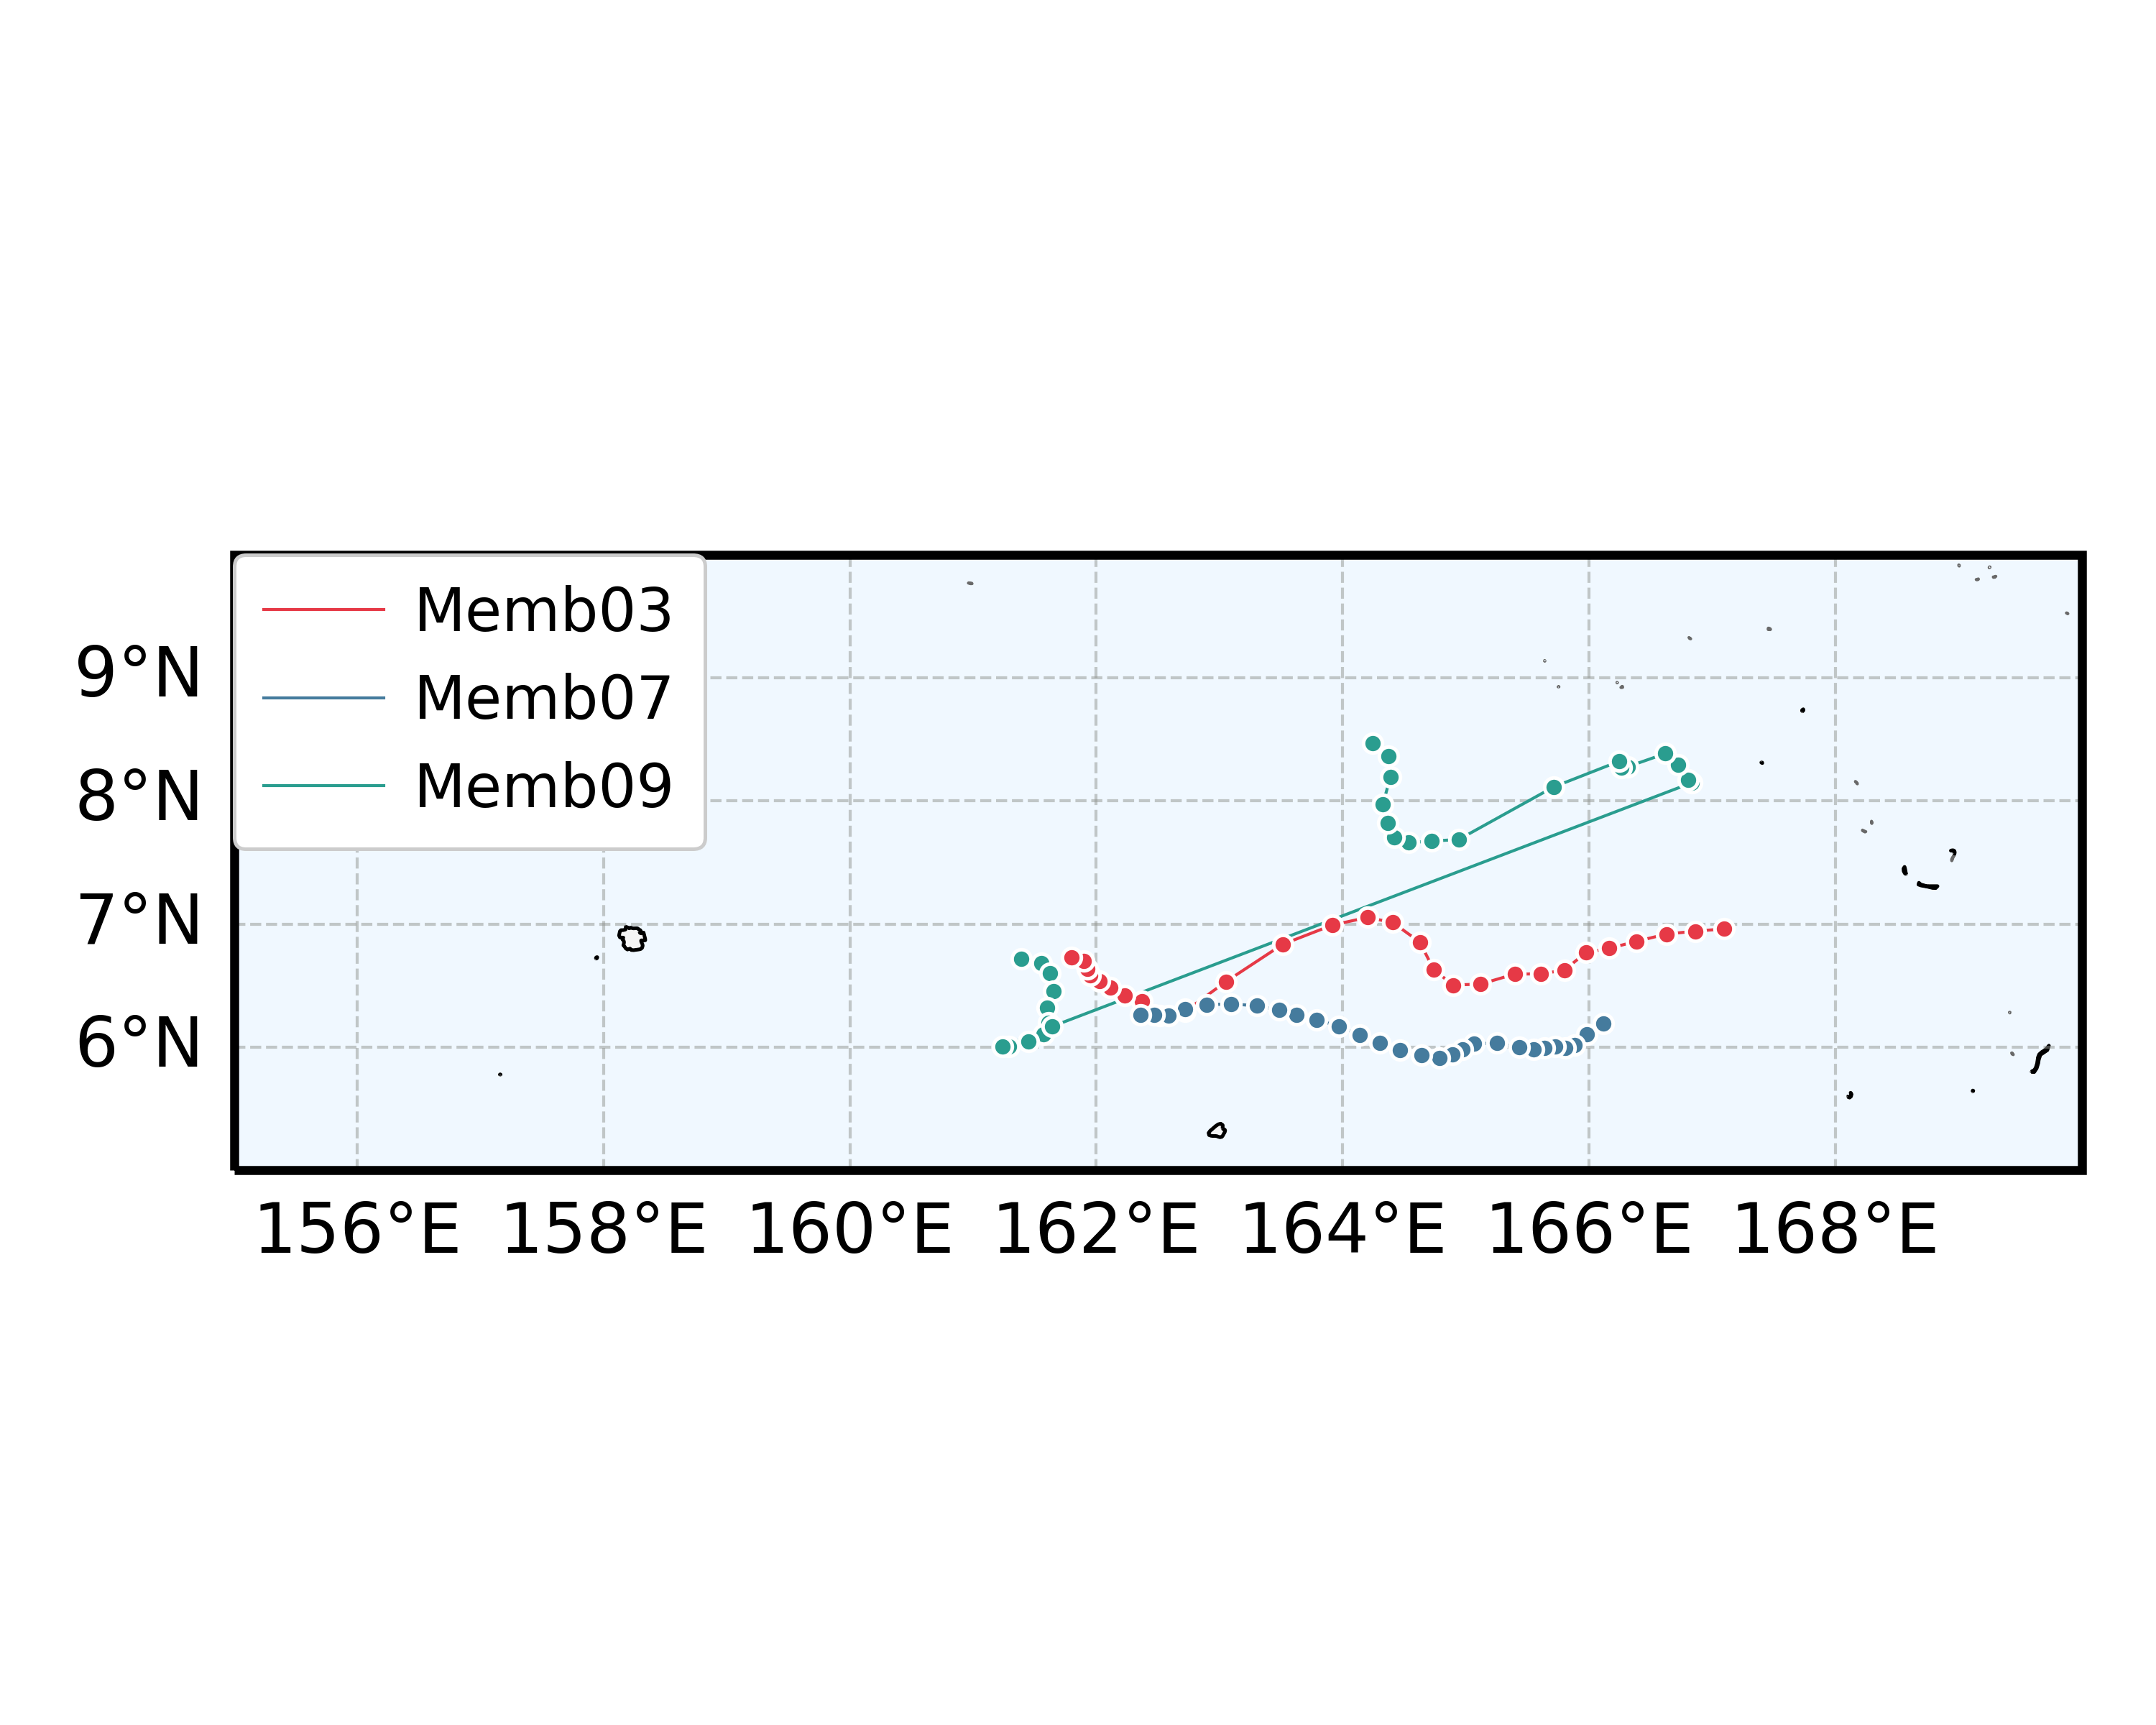

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- 1. Setup Data (Replace with your actual coordinates) ---
tracks = [
    {"name": "Memb03", "lons": trackdict['03']['clon'][13:13+28], "lats": trackdict['03']['clat'][13:13+28], "color": "#e63946"},
    {"name": "Memb07", "lons": trackdict['07']['clon'][13:13+28], "lats": trackdict['07']['clat'][13:13+28], "color": "#457b9d"},
    {"name": "Memb09", "lons": trackdict['09']['clon'][13:13+28], "lats": trackdict['09']['clat'][13:13+28], "color": "#2a9d8f"}
]

# --- 2. Initialize Figure ---
fig = plt.figure(figsize=(5,4), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

# Set Extent: [West, East, South, North] - Focus on WPAC
ax.set_extent([155, 170, 5, 10], crs=ccrs.PlateCarree())

# --- 3. Add High-Res Features (The "Pretty" Part) ---
# Add a subtle ocean color and land mask
ax.add_feature(cfeature.OCEAN, facecolor='#f0f8ff')
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5', edgecolor='dimgray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.4)

# Add Gridlines
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, 
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# --- 4. Plot Tracks ---
for track in tracks:
    # Plot the line
    ax.plot(track['lons'], track['lats'], color=track['color'], 
            linewidth=0.5, transform=ccrs.Geodetic(), label=track['name'],
            zorder=5)
    
    # Plot points (Markers for intensity or time steps)
    ax.scatter(track['lons'], track['lats'], color=track['color'], 
               edgecolor='white', s=10, transform=ccrs.PlateCarree(), 
               zorder=6)

# --- 5. Final Aesthetics ---
#plt.title("Tropical Cyclone Tracks - Western North Pacific", fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=1)

# Tight layout to remove excess whitespace
plt.tight_layout()
plt.savefig('./pics/TCtracks.png')
plt.show()

## Calculate

In [ ]:
tmpdict = {}
for memb in (['01','02','03','04','05','06','07','08','09','10']):
    track = xr.open_dataset(f'/glade/derecho/scratch/ihtam/temp/memb{memb}/track_avor_850-600.nc')
    ctrl_files = sorted(glob.glob(f"/glade/derecho/scratch/ihtam/temp/memb{memb}/wrfout_d02_2013-11-0*"))[:35]
    ctrl_mslp = []
    for i in tqdm(range(len(ctrl_files))):
        # read file
        nc_ctrl = Dataset(ctrl_files[i])
        # Target location
        target_lat = track['clat'][12+i]
        target_lon = track['clon'][12+i]
        # Compute track indices
        ix, iy = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
        # Read in max reflectivity
        ctrl_slp = getvar(nc_ctrl,'slp')
        # Find mslp
        try:
            ctrl_mslp.append(float(ctrl_slp[int(iy)-50:int(iy)+50,int(ix)-50:int(ix)+50].min()))
        except:
            ctrl_mslp.append(np.nan)
    tmpdict[memb] = ctrl_mslp

In [4]:
with open(f"./store/mslp_dict.pkl", "wb") as f:
    pickle.dump(tmpdict, f)

## Plot

In [5]:
tmpdict = open_pickle(f"./store/mslp_dict.pkl")

In [6]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 11.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 10,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_20004/4003527188.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


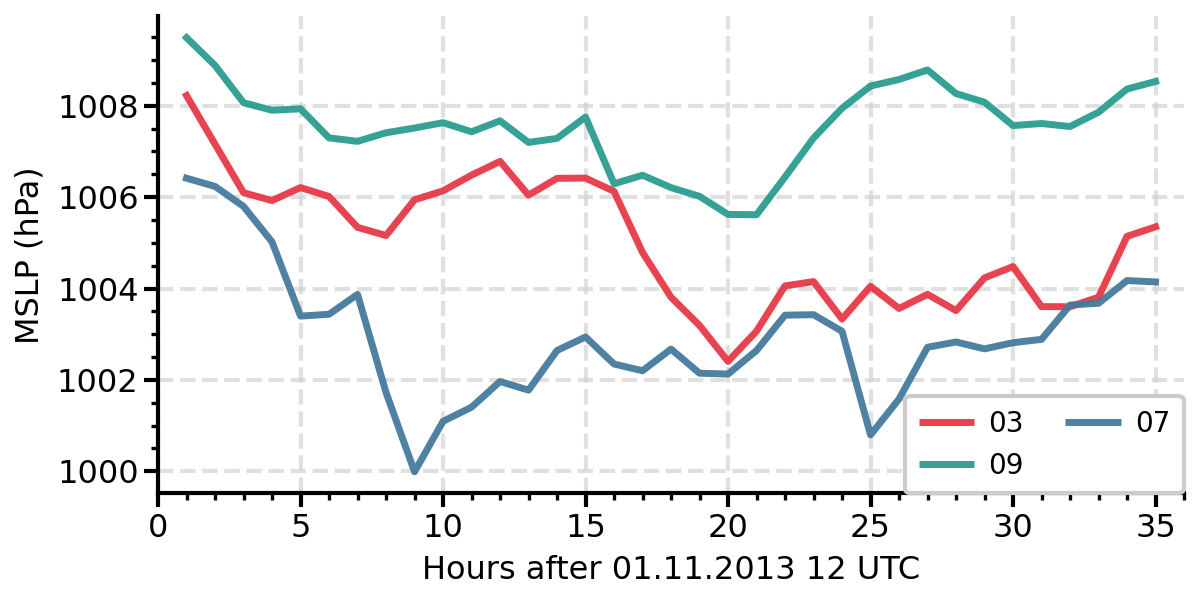

In [8]:
fig, axs = plot.subplots(ncols=1, figsize=(6,3), share=False)
#for memb in (['01','02','03','04','05','06','07','08','09','10']):
#    tmp = tmpdict[memb]
#    axs.plot(np.arange(1,len(tmp)+1),tmp,lw=0.75,alpha=0.79)#,label=memb)
axs.plot(np.arange(1,len(tmpdict["03"])+1),tmpdict['03'],lw=2.5,alpha=0.95,label='03',c="#e63946")
axs.plot(np.arange(1,len(tmpdict["03"])+1),tmpdict['07'],lw=2.5,alpha=0.95,label='07',c="#457b9d")
axs.plot(np.arange(1,len(tmpdict["03"])+1),tmpdict['09'],lw=2.5,alpha=0.95,label='09',c="#2a9d8f")
axs.format(xlim=(0,36),#ylim=(0,1),
           xlabel='Hours after 01.11.2013 12 UTC', ylabel='MSLP (hPa)')
plt.legend(loc=1,ncols=2)
#plt.savefig('./pics/conv_memb3.png',dpi=400)
plt.show()

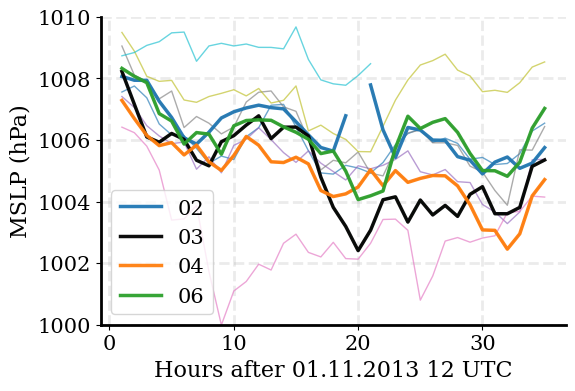

In [5]:
fig,ax = plt.subplots(1,1,figsize=(6,4))
for memb in (['01','02','03','04','05','06','07','08','09','10']):
    tmp = tmpdict[memb]
    plt.plot(np.arange(1,len(tmp)+1),tmp,lw=1,alpha=0.65)#,label=memb)
plt.plot(np.arange(1,len(tmp)+1),tmpdict['02'],lw=2.5,alpha=0.95,label='02')
plt.plot(np.arange(1,len(tmp)+1),tmpdict['03'],lw=2.5,alpha=0.95,label='03',c='k')
plt.plot(np.arange(1,len(tmp)+1),tmpdict['04'],lw=2.5,alpha=0.95,label='04')
plt.plot(np.arange(1,len(tmp)+1),tmpdict['06'],lw=2.5,alpha=0.95,label='06')
plt.grid(alpha=0.25,lw=2,ls='--')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylim(1000,1010)
plt.ylabel('MSLP (hPa)',fontsize=16)
plt.xlabel('Hours after 01.11.2013 12 UTC',fontsize=16)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
plt.legend()
plt.savefig('./pics/vmax.png',dpi=300)
plt.show()